# Сравнение средних

## Сравнение средних в рамках нормальной модели

Пусть для выборок $\vec{x_n}$, $\vec{y_m}$ априорно заданы нормальное распределения:
$$
\xi \sim N(a, \sigma_x^2), \newline
\eta \sim N(b, \sigma_y^2). \newline
$$
причём дисперсии законов известны.
Для проверки гипотезы равенства средних
$$
H_0: ~ a = b \newline
H_1: ~ a > b
$$
с уровнем значимости $\alpha = 0.05$ используем критерий
$$
\Delta = {\overline{x} - \overline{y} - (a - b) \over \sqrt{m\sigma_x^2 + n\sigma_y^2 \over nm}} \sim N(0, 1); \newline
\newline
H_0: G: \tilde{\Delta} > N_{1-\alpha}(0, 1)
$$

## Вычисление квантилей

In [1]:
from scipy.stats import norm
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# data init
X, N, DX = np.array([-1.11, -6.10, 2.42]), 3, 2
Y, M, DY = np.array([-2.29, -2.91]), 2, 1

# critical area
ALPHA = 0.05
C = norm.ppf(1 - ALPHA)

DELTA = (X.mean() - Y.mean()) / np.sqrt((M * DX + N * DY) / N / M)

In [3]:
def check_hypotesis(delta):
    if delta < C:
        return "Can't reject"
    return "Reject"

In [4]:
print(f"{check_hypotesis(DELTA)} means equality hypotesis")

Can't reject means equality hypotesis


## Построение графика $W(\theta)$

Где $\theta = a - b$

In [12]:
gamma = np.sqrt((M * DX + N * DY) / N / M)

def W(theta):
    return norm.sf(C - theta / gamma)

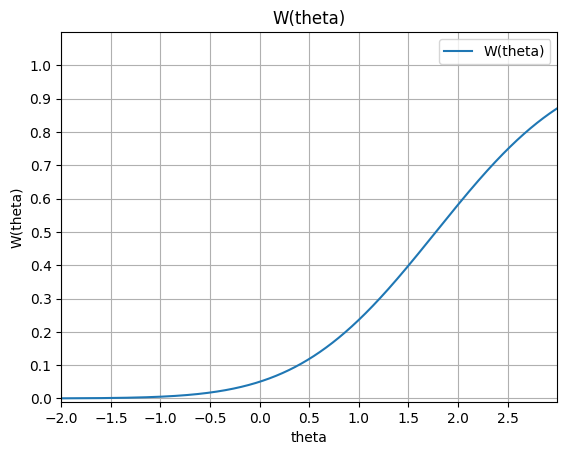

In [13]:
fig, axis = plt.subplots()
theta = np.linspace(-2, 3, 50000)

axis.plot(theta, W(theta), label="W(theta)")

axis.set_ylim(-0.01, 1.1)
axis.set_yticks(np.arange(0, 1.1, 0.1))
axis.set_ylabel("W(theta)")

axis.set_xlim(-2, 3)
axis.set_xticks(np.arange(-2, 3, 0.5))
axis.set_xlabel("theta")

axis.legend()
axis.set_title("W(theta)")

axis.grid(True)

plt.show()

In [14]:
W(DELTA)

np.float64(0.2162696968725109)